# 04_LinearRegression.ipynb

# 1. Introduction

## What is Linear Regression?

Linear Regression is a **supervised machine learning algorithm** used to predict a **continuous numerical value** by finding the best-fitting linear relationship between input features and the target.

---

## Why do we need it?

Suppose you want to predict:

* House Price
* Salary
* Temperature
* Sales
* Stock Demand

These are continuous values.

Linear Regression learns the relationship between features and the target so it can predict unseen values.

---

## Types of Linear Regression

### Simple Linear Regression

Uses **one** input feature.

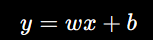

Example

```text
House Size  →  Price
```

---

### Multiple Linear Regression

Uses **multiple** input features.

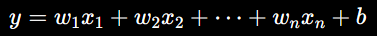

Example

```text
House Size
Bedrooms
Bathrooms
Location

↓

House Price
```

---

## Mathematical Intuition

Linear Regression tries to find the **best-fit line (or hyperplane)** that minimizes prediction error.

For one feature

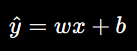

where

* (x) = Input feature
* (w) = Weight (Slope)
* (b) = Bias (Intercept)
* (\hat{y}) = Predicted value

---

## Cost Function

The model learns (w) and (b) by minimizing the **Mean Squared Error (MSE)**.

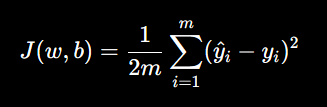

Gradient Descent (or a closed-form solver) is then used to find the optimal parameters.

> **Note:** Scikit-learn's `LinearRegression` uses the **Ordinary Least Squares (OLS)** solution by default, not Gradient Descent.

---

## Advantages

* Simple and easy to interpret.
* Fast to train.
* Works well for linear relationships.
* Coefficients are easy to understand.

---

## Disadvantages

* Assumes a linear relationship.
* Sensitive to outliers.
* Can underperform on complex non-linear data.
* May suffer from multicollinearity.

---

## Assumptions

* Linear relationship
* Independent observations
* Constant variance (Homoscedasticity)
* Low multicollinearity
* Normally distributed residuals (mainly for statistical inference)

---

## When to Use

✅ Continuous target variable

✅ Linear relationship

✅ Small to medium datasets

---

## When Not to Use

❌ Classification problems

❌ Highly non-linear relationships

❌ Large number of influential outliers

---

## Applications

* House Price Prediction
* Salary Prediction
* Sales Forecasting
* Demand Prediction
* Temperature Prediction
* Stock Trend Estimation (simple baseline)

---

## Linear Regression vs Logistic Regression

| Feature      | Linear Regression | Logistic Regression |
| ------------ | ----------------- | ------------------- |
| Problem Type | Regression        | Classification      |
| Target       | Continuous        | Categorical         |
| Output       | Any real value    | Probability (0–1)   |
| Activation   | None              | Sigmoid             |
| Example      | House Price       | Spam Detection      |

---

## Workflow

```text
Input Features
        │
        ▼
Learn Best Line
        │
        ▼
Predict Continuous Value
```

---

# 2. Import & Constructor

## Import

```python
from sklearn.linear_model import LinearRegression
```

Create the model

```python
model = LinearRegression()
```

---

## Constructor Syntax

```python
LinearRegression(
    *,
    fit_intercept=True,
    copy_X=True,
    tol=1e-6,
    n_jobs=None,
    positive=False
)
```

---

## Constructor Parameters

| Parameter       | Default | Description                                        | Common Usage           |
| --------------- | ------- | -------------------------------------------------- | ---------------------- |
| `fit_intercept` | `True`  | Calculates the intercept (bias) term.              | Keep `True`            |
| `copy_X`        | `True`  | Copies the input data before fitting.              | Keep `True`            |
| `tol`           | `1e-6`  | Tolerance for convergence (used with sparse data). | Keep default           |
| `n_jobs`        | `None`  | Number of CPU cores used for computation.          | `-1` to use all cores  |
| `positive`      | `False` | Forces coefficients to be non-negative.            | Use only when required |

---

## Important Parameters

### `fit_intercept`

Default

```python
fit_intercept=True
```

Learns the bias (`b`) in

[
\hat{y}=wx+b
]

If

```python
fit_intercept=False
```

the model assumes

[
b=0
]

Use `False` **only if your data is already centered around zero**.

---

### `copy_X`

Default

```python
copy_X=True
```

* `True` → Creates a copy of the input data.
* `False` → May modify the original data to save memory.

Recommended: **Keep `True`**.

---

### `tol`

Default

```python
tol=1e-6
```

Tolerance used when fitting **sparse datasets**.

For most dense datasets, changing this parameter has little or no effect.

---

### `n_jobs`

Default

```python
n_jobs=None
```

Controls parallel processing.

* `None` → Single core (default behavior).
* `-1` → Uses all available CPU cores.

Useful for very large datasets or multi-target regression.

---

### `positive`

Default

```python
positive=True
```

Allows only **non-negative coefficients**.

Example

```text
Weight = 2.5
Area = 1.8
Distance = 0.0
```

Negative coefficients are not allowed.

Useful in domains where feature contributions must be positive (e.g., some economics or scientific applications).

---

## Recommended Settings

### General Use

```python
model = LinearRegression()
```

---

### Large Dataset

```python
model = LinearRegression(
    n_jobs=-1
)
```

---

### Positive Coefficients Only

```python
model = LinearRegression(
    positive=True
)
```

---

### Summary

| Parameter       | Most Common Value |
| --------------- | ----------------- |
| `fit_intercept` | `True`            |
| `copy_X`        | `True`            |
| `tol`           | `1e-6`            |
| `n_jobs`        | `None`            |
| `positive`      | `False`           |

> **Note:** Unlike many machine learning algorithms, `LinearRegression` has **very few hyperparameters** because Ordinary Least Squares (OLS) computes the optimal coefficients directly rather than searching through many configurable settings.

# 3. Methods & Attributes

## Methods

| Method         | Purpose                                              | Returns          |
| -------------- | ---------------------------------------------------- | ---------------- |
| `fit(X, y)`    | Learns the relationship between features and target. | Model object     |
| `predict(X)`   | Predicts target values for new data.                 | Predicted values |
| `score(X, y)`  | Returns the R² score of the model.                   | Float            |
| `get_params()` | Returns constructor parameters.                      | Dictionary       |
| `set_params()` | Updates constructor parameters.                      | Model object     |

---

## Most Used Methods

| Method         | Usage              |
| -------------- | ------------------ |
| `fit()`        | Train the model    |
| `predict()`    | Predict new values |
| `score()`      | Evaluate using R²  |
| `get_params()` | View parameters    |
| `set_params()` | Modify parameters  |

---

## Attributes

After calling `fit()`, the model stores the following information.

| Attribute           | Description                                              |
| ------------------- | -------------------------------------------------------- |
| `coef_`             | Coefficient (weight) of each feature.                    |
| `intercept_`        | Bias (intercept) of the regression equation.             |
| `rank_`             | Rank of the feature matrix (dense data only).            |
| `singular_`         | Singular values of the feature matrix (dense data only). |
| `n_features_in_`    | Number of input features.                                |
| `feature_names_in_` | Input feature names (DataFrame only).                    |

---

## Example

```python
import pandas as pd
from sklearn.linear_model import LinearRegression

X = pd.DataFrame({
    "Area": [1000, 1200, 1500, 1800]
})

y = [50, 60, 75, 90]

model = LinearRegression()

model.fit(X, y)

print(model.coef_)
print(model.intercept_)
print(model.n_features_in_)
print(model.feature_names_in_)
```

Output (approx.)

```text
coef_ :
[0.05]

intercept_ :
0.0

n_features_in_ :
1

feature_names_in_ :
['Area']
```

---

## Understanding `coef_`

For

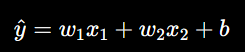

`coef_` stores

```text
[w₁, w₂, w₃, ...]
```

Example

```python
model.coef_

array([2.5, -1.2, 0.8])
```

means

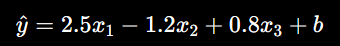

---

## Understanding `intercept_`

Stores the **bias** (`b`).

Example

```python
model.intercept_

10.4
```

Regression equation becomes

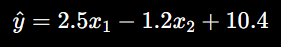

---

## Most Frequently Used Attributes

| Attribute           | Importance |
| ------------------- | ---------- |
| `coef_`             | ⭐⭐⭐⭐⭐      |
| `intercept_`        | ⭐⭐⭐⭐⭐      |
| `n_features_in_`    | ⭐⭐⭐        |
| `feature_names_in_` | ⭐⭐⭐        |
| `rank_`             | ⭐⭐         |
| `singular_`         | ⭐          |

> **Note:** The two attributes you'll use most in practice are `coef_` and `intercept_`, since together they define the learned regression equation. The remaining attributes are mainly useful for debugging or inspecting the fitted model.

# 4. End-to-End Workflow

## Workflow

```text
Load Dataset
      ↓
Train-Test Split
      ↓
(Optional) Scale Features
      ↓
Create LinearRegression Model
      ↓
Train Model (fit)
      ↓
Predict (predict)
      ↓
Evaluate Model
```

> **Note:** Feature scaling is **optional** for `LinearRegression` (recommended when features have very different scales or when using regularized models like Ridge/Lasso).

---

## Complete Example

```python
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Load Dataset
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling (Optional)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Model
model = LinearRegression()

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))
```

---

## Important Notes

* Split the dataset before preprocessing.
* Fit the model using **training data only**.
* Use `predict()` for unseen data.
* Evaluate on the **test set**.
* Scale features only when appropriate.

---

# 5. Common Errors

| Mistake                                                       | Why It Happens                                                         |
| ------------------------------------------------------------- | ---------------------------------------------------------------------- |
| Using `predict()` before `fit()`                              | The model has not been trained yet.                                    |
| Training on the entire dataset                                | Prevents proper evaluation and may lead to overestimating performance. |
| Evaluating on training data only                              | Does not measure how well the model generalizes to unseen data.        |
| Ignoring missing values                                       | `LinearRegression` cannot handle `NaN` values directly.                |
| Using categorical features without encoding                   | The algorithm accepts only numerical input.                            |
| Forgetting to preprocess new data                             | Prediction data must undergo the same preprocessing as training data.  |
| Expecting Linear Regression to model non-linear relationships | It assumes a linear relationship between features and the target.      |
| Ignoring outliers                                             | Outliers can significantly affect the fitted regression line.          |

---

## Hyperparameter Tuning

`LinearRegression` has very few hyperparameters, so tuning is usually minimal.

| Parameter       | Typical Value | When to Change                                          |
| --------------- | ------------- | ------------------------------------------------------- |
| `fit_intercept` | `True`        | Set `False` if data is already centered.                |
| `positive`      | `False`       | Set `True` when coefficients must be non-negative.      |
| `n_jobs`        | `None`        | Use `-1` for large datasets or multi-target regression. |

---